# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 2: Load Iris Dataset

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [4]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


# Step 3: Remove Labels

In [5]:
X = df

In [6]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


# Step 4: Train KMeans

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

# Step 5: Get Cluster Labels

In [9]:
clusters = kmeans.labels_

print(clusters[:100])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


# Step 6: Add Cluster Column

In [11]:
df["Cluster"] = clusters

print(df.head())
print("----------")
print(df.tail())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  
----------
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9         

# Step 7: See Cluster Centers

In [12]:
print(kmeans.cluster_centers_)

[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


## Visualize Using PCA

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.iloc[:, :-1])

# Step 8: Scatter Plot

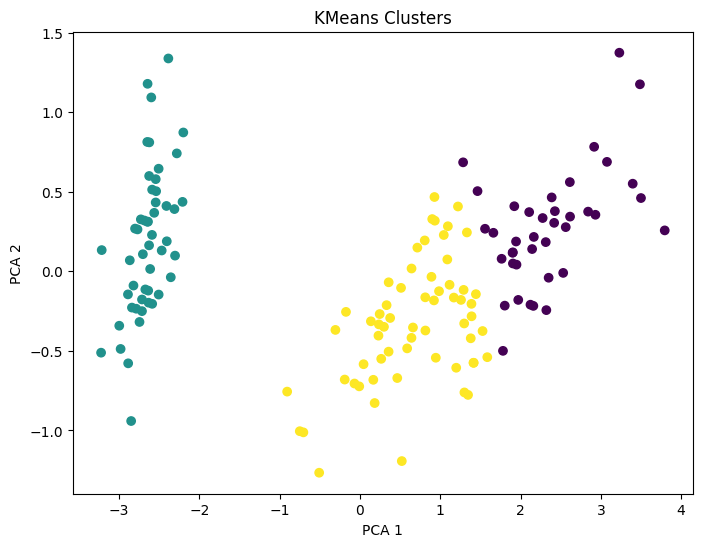

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("KMeans Clusters")

plt.show()

# Verify Using Actual Labels

In [15]:
species = iris.target_names

print(species)

['setosa' 'versicolor' 'virginica']


In [23]:
comparison = pd.DataFrame({
    "Actual": y,
    "Cluster": clusters
})

print(comparison.head(20))

    Actual  Cluster
0        0        1
1        0        1
2        0        1
3        0        1
4        0        1
5        0        1
6        0        1
7        0        1
8        0        1
9        0        1
10       0        1
11       0        1
12       0        1
13       0        1
14       0        1
15       0        1
16       0        1
17       0        1
18       0        1
19       0        1


# Confusion Matrix

In [24]:
from sklearn.metrics import confusion_matrix

print(
    confusion_matrix(
        y,
        clusters
    )
)

[[ 0 50  0]
 [ 3  0 47]
 [36  0 14]]


# Finding Best K (Elbow Method)

In [25]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X)

    wcss.append(model.inertia_)

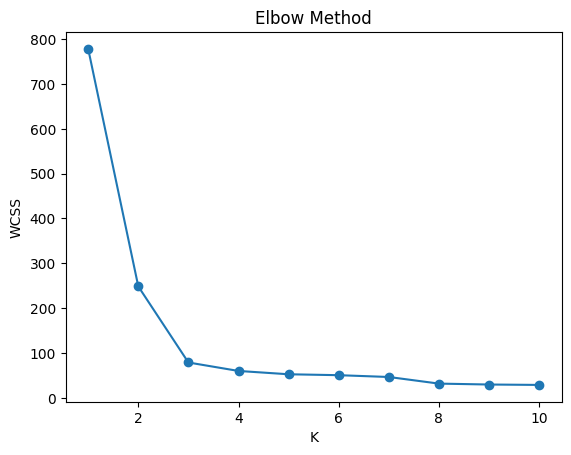

In [26]:
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()